In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv('data/netflix_titles.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (8807, 12)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [6]:
# Identifico los tipos de datos y los valores nulos
print("=== INFO ===")
df.info()


print("\n=== VALORES NULOS ===")
print(df.isnull().sum())

=== INFO ===
<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB

=== VALORES NULOS ===
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description   

In [4]:
print("\n=== DUPLICADOS ===")
print(f"Filas duplicadas: {df.duplicated().sum()}")


=== DUPLICADOS ===
Filas duplicadas: 0


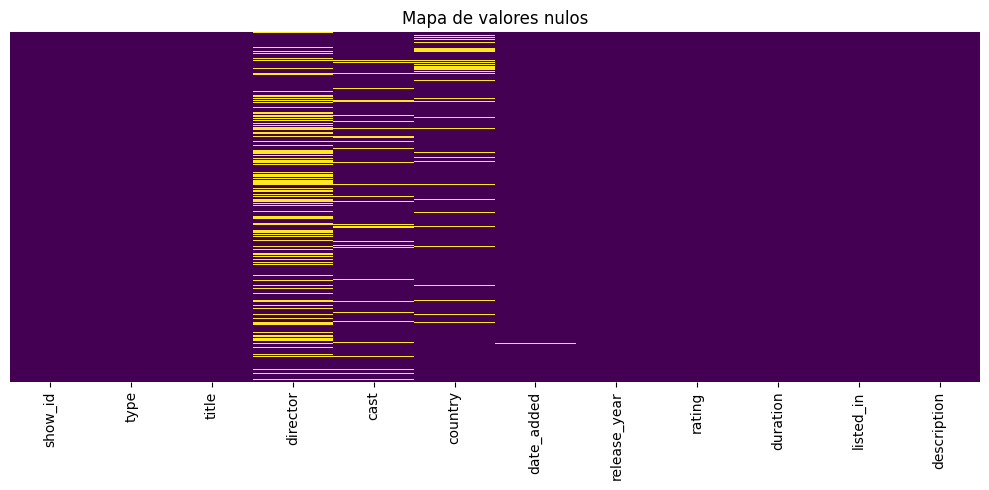

In [5]:
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Mapa de valores nulos')
plt.tight_layout()
plt.show()

In [8]:
# % de nulos por columna
# null_pct ---> null porcentage

null_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print(null_pct[null_pct > 0])

director      29.908028
country        9.435676
cast           9.367549
date_added     0.113546
rating         0.045418
duration       0.034064
dtype: float64


In [9]:
# Rellenar columnas con valor desconocido o unknown

cols_unknown = ['director', 'cast', 'country']
df[cols_unknown] = df[cols_unknown].fillna('Unknown')


# Para rating usando la moda

df['rating'] = df['rating'].fillna(df['rating'].mode()[0])


# Para duration también la moda

df['duration'] = df['duration'].fillna(df['duration'].mode()[0])

# Eliminar filas donde date added sea nulo

df = df.dropna(subset=['date_added'])

print("\nNulos restantes:")
print(df.isnull().sum())


Nulos restantes:
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64


In [10]:
# Limpiar espacios en blanco de date added

df['date_added'] = df['date_added'].str.strip()

# Convertir a datetime

df['date_added'] = pd.to_datetime(df['date_added'], format='%B %d, %Y')

# Extraer año y mes como columnas nuevas

df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

df[['date_added', 'year_added', 'month_added']].head()

,date_added,year_added,month_added
0,2021-09-25,2021,9
1,2021-09-24,2021,9
2,2021-09-24,2021,9
3,2021-09-24,2021,9
4,2021-09-24,2021,9


In [14]:
# Limpiar columna de duration

df['duration_value'] = df['duration'].str.extract(r'(\d+)').astype(float)
df['duration_unit'] = df['duration'].str.extract(r'([A-Za-z]+)')

df[['duration', 'duration_value', 'duration_unit']].head(10)

,duration,duration_value,duration_unit
0,90 min,90.0,min
1,2 Seasons,2.0,Seasons
2,1 Season,1.0,Season
3,1 Season,1.0,Season
4,2 Seasons,2.0,Seasons
5,1 Season,1.0,Season
6,91 min,91.0,min
7,125 min,125.0,min
8,9 Seasons,9.0,Seasons
9,104 min,104.0,min


In [16]:
# Estadizar el tipo de movie o TV show
df['type'] = df['type'].str.strip().str.title()
print(df['type'].value_counts())

# Estandarizar rating

df['rating'] = df['rating'].str.strip().str.upper()

# Ver valores unicos de rating

print(df['rating'].value_counts())

type
Movie      6131
Tv Show    2666
Name: count, dtype: int64
rating
TV-MA       3209
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 MIN         1
84 MIN         1
66 MIN         1
Name: count, dtype: int64


In [ ]:
print(f"Rango de años: {df['release_year'].min()} - {df['release_year'].max()}")

# Filtrar años incoherentes 

df = df[df['release_year'] >= 1900]
df = df[df['release_year'] <= 2024]

print(f"Registros válidos: {len(df)}")